In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/processed/cpcb_pm25_clean.csv")
print(f"Shape: {df.shape}")
print(f"States covered: {df['state'].nunique()}")
print(f"Cities covered: {df['city'].nunique()}")
print(f"Stations: {df['station'].nunique()}")
print(f"\nPM2.5 stats:")
print(df["pm25"].describe())

Shape: (464, 12)
States covered: 29
Cities covered: 238
Stations: 464

PM2.5 stats:
count    464.000000
mean      58.159483
std       36.221666
min        2.000000
25%       33.000000
50%       50.000000
75%       74.000000
max      238.000000
Name: pm25, dtype: float64


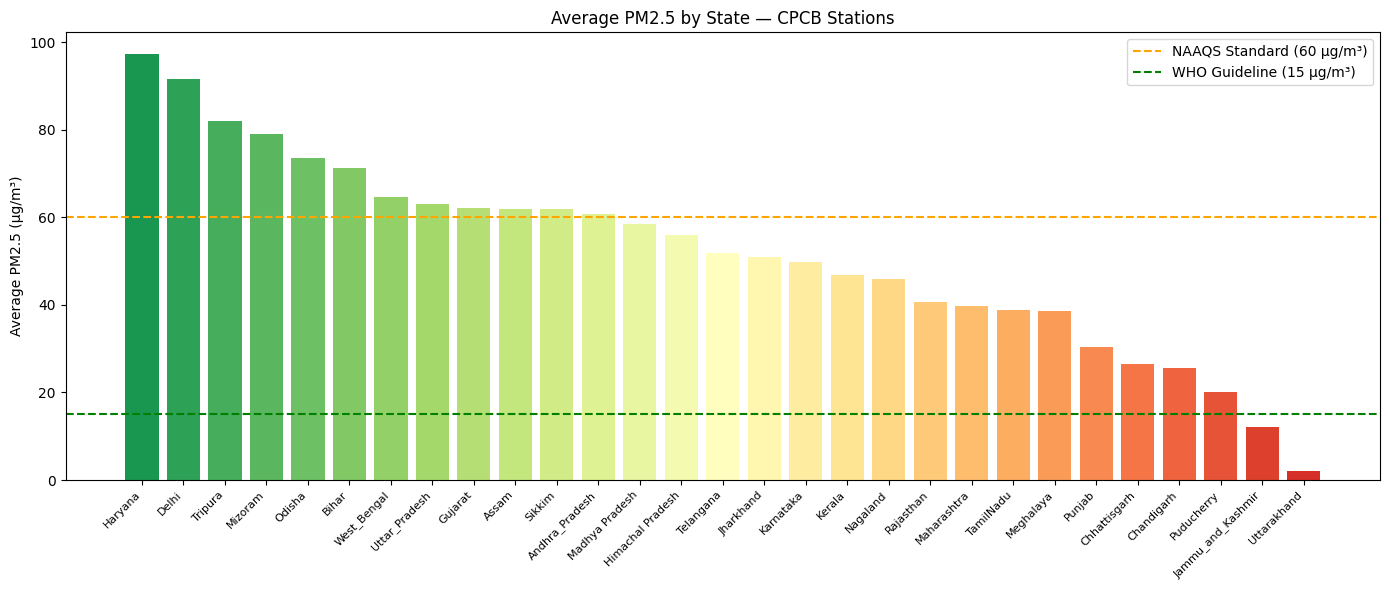

In [2]:
state_avg = df.groupby("state")["pm25"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
colors = cm.RdYlGn_r(np.linspace(0.1, 0.9, len(state_avg)))
plt.bar(state_avg.index, state_avg.values, color=colors)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.ylabel("Average PM2.5 (µg/m³)")
plt.title("Average PM2.5 by State — CPCB Stations")
plt.axhline(60, color="orange", linestyle="--", label="NAAQS Standard (60 µg/m³)")
plt.axhline(15, color="green", linestyle="--", label="WHO Guideline (15 µg/m³)")
plt.legend()
plt.tight_layout()
plt.savefig("../docs/pm25_by_state.png", dpi=150)
plt.show()

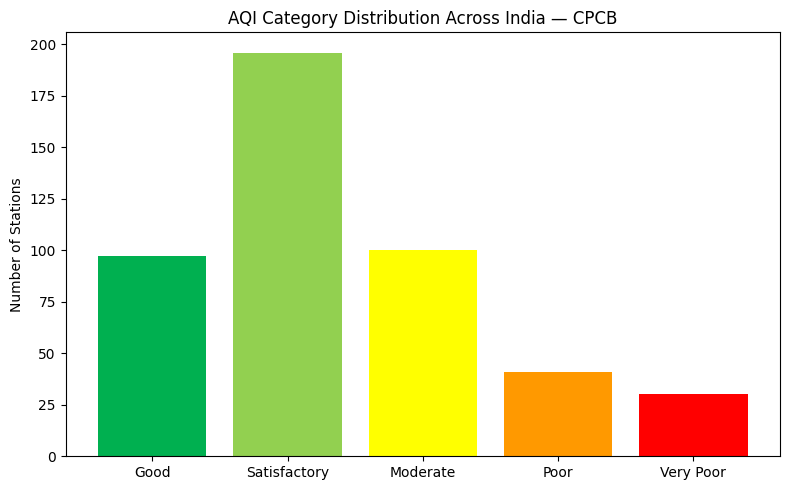

aqi_category
Good             97.0
Satisfactory    196.0
Moderate        100.0
Poor             41.0
Very Poor        30.0
Name: count, dtype: float64


In [3]:
cat_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
cat_colors = ["#00b050", "#92d050", "#ffff00", "#ff9900", "#ff0000", "#7030a0"]
counts = df["aqi_category"].value_counts().reindex(cat_order).dropna()

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color=cat_colors[:len(counts)])
plt.ylabel("Number of Stations")
plt.title("AQI Category Distribution Across India — CPCB")
plt.tight_layout()
plt.savefig("../docs/aqi_distribution.png", dpi=150)
plt.show()

print(counts)

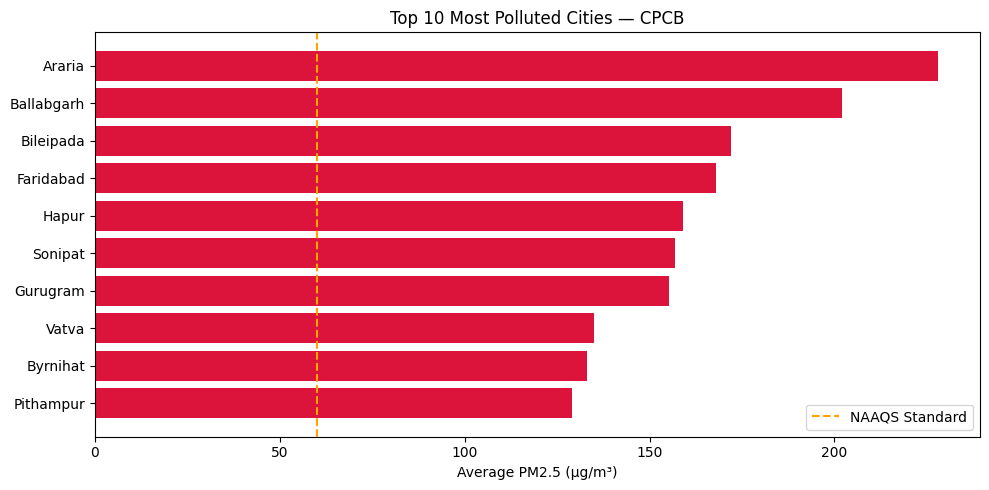

In [4]:
city_avg = df.groupby("city")["pm25"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(city_avg.index[::-1], city_avg.values[::-1], color="crimson")
plt.xlabel("Average PM2.5 (µg/m³)")
plt.title("Top 10 Most Polluted Cities — CPCB")
plt.axvline(60, color="orange", linestyle="--", label="NAAQS Standard")
plt.legend()
plt.tight_layout()
plt.savefig("../docs/top10_polluted.png", dpi=150)
plt.show()

In [5]:
import folium

m = folium.Map(location=[22.5, 80.0], zoom_start=5, tiles="CartoDB positron")

color_map = {
    "Good": "green",
    "Satisfactory": "lightgreen", 
    "Moderate": "orange",
    "Poor": "red",
    "Very Poor": "darkred",
    "Severe": "purple"
}

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6,
        color=color_map.get(row["aqi_category"], "gray"),
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['station']}<br>{row['city']}, {row['state']}<br>PM2.5: {row['pm25']} µg/m³<br>{row['aqi_category']}"
    ).add_to(m)

m.save("../docs/india_pm25_map.html")
print("Map saved to docs/india_pm25_map.html — open it in your browser!")
m

Map saved to docs/india_pm25_map.html — open it in your browser!
